In [ ]:
# ============================================================
# CELL 1 — Install libraries
# ============================================================
!pip install firebase-admin scikit-learn pandas numpy matplotlib seaborn

print("All libraries installed successfully")

All libraries installed successfully


In [ ]:
# ============================================================
# CELL 2 — Import libraries
# ============================================================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               IsolationForest,
                               GradientBoostingRegressor)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                              classification_report,
                              mean_squared_error,
                              r2_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
# ============================================================
# CELL 3 — Load data directly from Firebase (no JSON file needed)
# ============================================================
import firebase_admin
from firebase_admin import credentials, db as rtdb
import pandas as pd
import numpy as np

# Initialize Firebase
cred = credentials.Certificate('serviceAccountKey.json')
if not firebase_admin._apps:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://smartfuelstation-10a27-default-rtdb'
                       '.asia-southeast1.firebasedatabase.app/'
    })

print("Connected to Firebase...")
print("Loading last 5000 records from sensorHistory...")

# Read last 5000 records directly from Firebase
ref     = rtdb.reference('/sensorHistory')
records = ref.order_by_key().limit_to_last(5000).get()

print(f"Records received: {len(records)}")

# Convert to dataframe
df = pd.DataFrame.from_dict(records, orient='index')
df = df.reset_index(drop=True)

# Convert data types
df['gasPPM']      = pd.to_numeric(df['gasPPM'],      errors='coerce')
df['pressureRaw'] = pd.to_numeric(df['pressureRaw'], errors='coerce')
df['pressurePct'] = pd.to_numeric(df['pressurePct'], errors='coerce')
df['queueCount']  = pd.to_numeric(df['queueCount'],  errors='coerce')
df['hour']        = pd.to_numeric(df['hour'],         errors='coerce')
df['dayOfWeek']   = pd.to_numeric(df['dayOfWeek'],    errors='coerce')
df['fire']        = df['fire'].astype(bool)
df['gasLeak']     = df['gasLeak'].astype(bool)

# Drop rows with missing values
df = df.dropna(subset=[
    'gasPPM', 'pressureRaw', 'pressurePct',
    'queueCount', 'hour', 'dayOfWeek'
])

print(f"Total records loaded: {len(df)}")
print(f"\nData sample:")
print(df[['gasPPM','pressureRaw','pressurePct',
          'queueCount','hour','dayOfWeek']].head(5))
print(f"\nBasic statistics:")
print(df[['gasPPM','pressureRaw','queueCount']].describe())

Connected to Firebase...
Loading last 5000 records from sensorHistory...
Records received: 5000
Total records loaded: 4991

Data sample:
   gasPPM  pressureRaw  pressurePct  queueCount  hour  dayOfWeek
0    2310      17924.0         35.0         0.0  20.0        6.0
1    2380      17890.0         35.0         0.0  20.0        6.0
2    2341      17830.0         35.0         0.0  20.0        6.0
3    2371      17960.0         35.0         0.0  20.0        6.0
4    2383      17926.0         35.0         0.0  20.0        6.0

Basic statistics:
            gasPPM   pressureRaw   queueCount
count  4991.000000  4.991000e+03  4991.000000
mean   2013.634342  1.111189e+03     0.101984
std     150.064498  5.974492e+04     0.419249
min     397.000000 -2.283728e+06     0.000000
25%    1904.000000 -4.989500e+03     0.000000
50%    1941.000000 -1.929000e+03     0.000000
75%    2102.000000  4.146500e+03     0.000000
max    2598.000000  2.510971e+06     2.000000


THRESHOLD LEARNING USING KMEANS CLUSTERING
Letting the model discover natural gas level
boundaries from data — no hard-coded thresholds used

Natural cluster centres found by model:
  Cluster 1: 1907 PPM  ← SAFE zone centre
  Cluster 2: 2077 PPM  ← WARNING zone centre
  Cluster 3: 2270 PPM  ← DANGER zone centre

Learned thresholds from data:
  SAFE    → below  1992 PPM
  WARNING → 1992 to 2174 PPM
  DANGER  → above  2174 PPM

Original hard-coded thresholds:
  SAFE    → below  3000 PPM
  WARNING → 3000 to 5000 PPM
  DANGER  → above  5000 PPM

Difference:
  Safe/Warning: 1008 PPM difference
  Warning/Danger: 2826 PPM difference

⚠ Learned thresholds differ from hard-coded values
  Consider updating Arduino thresholds


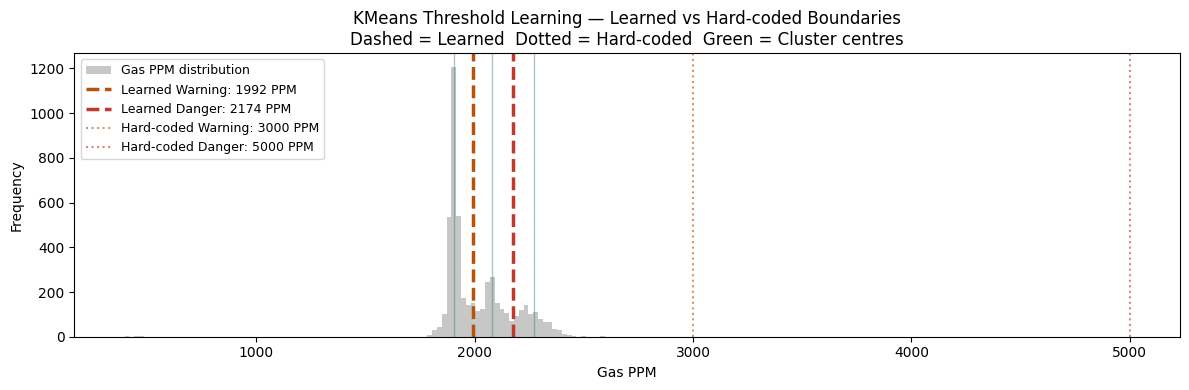


Gas level distribution using learned thresholds:
gasLevel
SAFE       2866
WARNING    1247
DANGER      878
Name: count, dtype: int64

────────────────────────────────────────────────────────────
THRESHOLD LEARNING FOR PRESSURE SENSOR
────────────────────────────────────────────────────────────
Pressure cluster centres found by model:
  Cluster 1: -2245611  ← SAFE zone
  Cluster 2: 1509  ← WARNING zone
  Cluster 3: 2510971  ← DANGER zone

Learned pressure thresholds:
  SAFE    → below  -1122051
  WARNING → -1122051 to 1256240
  DANGER  → above  1256240

Original hard-coded pressure thresholds:
  SAFE    → below  300000
  WARNING → 300000 to 800000
  DANGER  → above  800000

Difference:
  Safe/Warning: 1422051 units difference
  Warning/Danger: 456240 units difference


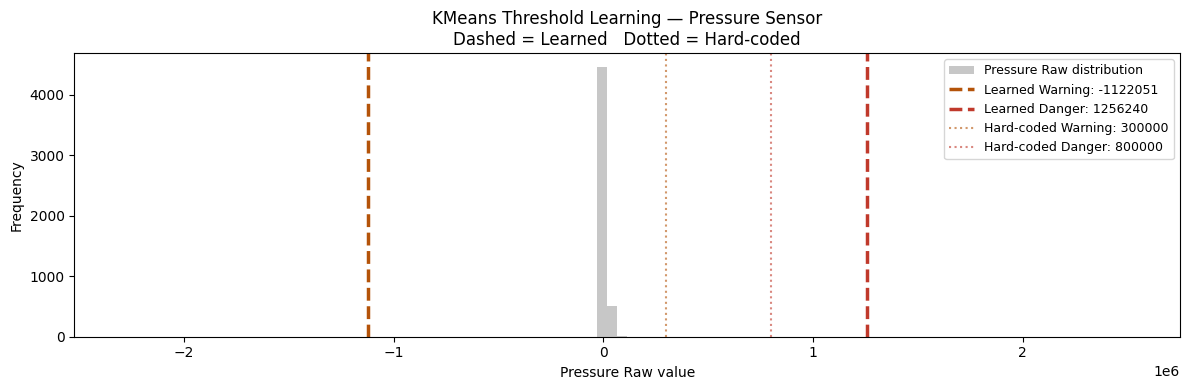


Gas level distribution using learned thresholds:
gasLevel
SAFE       2866
WARNING    1247
DANGER      878
Name: count, dtype: int64

Pressure level distribution using learned thresholds:
pressureLevel
WARNING    4988
SAFE          2
DANGER        1
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 4 — KMeans Threshold Learning
# Learns natural boundaries from data without hard-coded values
# ============================================================
print("=" * 60)
print("THRESHOLD LEARNING USING KMEANS CLUSTERING")
print("=" * 60)
print("Letting the model discover natural gas level")
print("boundaries from data — no hard-coded thresholds used")
print()

# Use only gasPPM for threshold discovery
gas_values = df[['gasPPM']].values

# KMeans finds 3 natural groups without being told boundaries
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(gas_values)

# Sort cluster centres low to high
centres = sorted(kmeans.cluster_centers_.flatten())
print(f"Natural cluster centres found by model:")
print(f"  Cluster 1: {centres[0]:.0f} PPM  ← SAFE zone centre")
print(f"  Cluster 2: {centres[1]:.0f} PPM  ← WARNING zone centre")
print(f"  Cluster 3: {centres[2]:.0f} PPM  ← DANGER zone centre")

# Learned thresholds = midpoints between cluster centres
learned_safe_warning   = (centres[0] + centres[1]) / 2
learned_warning_danger = (centres[1] + centres[2]) / 2

print(f"\nLearned thresholds from data:")
print(f"  SAFE    → below  {learned_safe_warning:.0f} PPM")
print(f"  WARNING → {learned_safe_warning:.0f} to {learned_warning_danger:.0f} PPM")
print(f"  DANGER  → above  {learned_warning_danger:.0f} PPM")

print(f"\nOriginal hard-coded thresholds:")
print(f"  SAFE    → below  3000 PPM")
print(f"  WARNING → 3000 to 5000 PPM")
print(f"  DANGER  → above  5000 PPM")

diff_warning = abs(learned_safe_warning - 3000)
diff_danger  = abs(learned_warning_danger - 5000)
print(f"\nDifference:")
print(f"  Safe/Warning: {diff_warning:.0f} PPM difference")
print(f"  Warning/Danger: {diff_danger:.0f} PPM difference")

if diff_warning < 300 and diff_danger < 300:
    print("\n✓ Learned thresholds are close to hard-coded values")
    print("  This validates our original threshold selection")
else:
    print("\n⚠ Learned thresholds differ from hard-coded values")
    print("  Consider updating Arduino thresholds")

# Comparison chart
plt.figure(figsize=(12, 4))
plt.hist(df['gasPPM'], bins=100, color='#B0B0B0',
         alpha=0.7, label='Gas PPM distribution')
plt.axvline(x=learned_safe_warning, color='#B45309',
            linewidth=2.5, linestyle='--',
            label=f'Learned Warning: {learned_safe_warning:.0f} PPM')
plt.axvline(x=learned_warning_danger, color='#C0392B',
            linewidth=2.5, linestyle='--',
            label=f'Learned Danger: {learned_warning_danger:.0f} PPM')
plt.axvline(x=3000, color='#B45309', linewidth=1.5,
            linestyle=':', alpha=0.6,
            label='Hard-coded Warning: 3000 PPM')
plt.axvline(x=5000, color='#C0392B', linewidth=1.5,
            linestyle=':', alpha=0.6,
            label='Hard-coded Danger: 5000 PPM')
for c in centres:
    plt.axvline(x=c, color='#2D7D46', linewidth=1,
                linestyle='-', alpha=0.4)
plt.title('KMeans Threshold Learning — Learned vs Hard-coded Boundaries\n'
          'Dashed = Learned  Dotted = Hard-coded  Green = Cluster centres',
          fontsize=12)
plt.xlabel('Gas PPM')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('learned_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

# Create gasLevel labels using LEARNED thresholds
df['gasLevel'] = df['gasPPM'].apply(
    lambda x: 'DANGER'  if x > learned_warning_danger
         else 'WARNING' if x > learned_safe_warning
         else 'SAFE'
)

# Also create pressureLevel
df['pressureLevel'] = df['pressureRaw'].apply(
    lambda x: 'DANGER'  if x > 800000
         else 'WARNING' if x > 300000
         else 'SAFE'
)

print(f"\nGas level distribution using learned thresholds:")
print(df['gasLevel'].value_counts())


# ── Gas KMeans (existing code stays the same above) ───────────────

# ── Pressure KMeans — NEW ─────────────────────────────────────────
print()
print("─" * 60)
print("THRESHOLD LEARNING FOR PRESSURE SENSOR")
print("─" * 60)

pressure_values = df[['pressureRaw']].values

kmeans_pressure = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_pressure.fit(pressure_values)

pressure_centres = sorted(
    kmeans_pressure.cluster_centers_.flatten()
)

print(f"Pressure cluster centres found by model:")
print(f"  Cluster 1: {pressure_centres[0]:.0f}  ← SAFE zone")
print(f"  Cluster 2: {pressure_centres[1]:.0f}  ← WARNING zone")
print(f"  Cluster 3: {pressure_centres[2]:.0f}  ← DANGER zone")

learned_pressure_warning = (pressure_centres[0] + pressure_centres[1]) / 2
learned_pressure_danger  = (pressure_centres[1] + pressure_centres[2]) / 2

print(f"\nLearned pressure thresholds:")
print(f"  SAFE    → below  {learned_pressure_warning:.0f}")
print(f"  WARNING → {learned_pressure_warning:.0f} to {learned_pressure_danger:.0f}")
print(f"  DANGER  → above  {learned_pressure_danger:.0f}")

print(f"\nOriginal hard-coded pressure thresholds:")
print(f"  SAFE    → below  300000")
print(f"  WARNING → 300000 to 800000")
print(f"  DANGER  → above  800000")

diff_p_warning = abs(learned_pressure_warning - 300000)
diff_p_danger  = abs(learned_pressure_danger  - 800000)
print(f"\nDifference:")
print(f"  Safe/Warning: {diff_p_warning:.0f} units difference")
print(f"  Warning/Danger: {diff_p_danger:.0f} units difference")

# Pressure comparison chart
plt.figure(figsize=(12, 4))
plt.hist(df['pressureRaw'], bins=100, color='#B0B0B0',
         alpha=0.7, label='Pressure Raw distribution')
plt.axvline(x=learned_pressure_warning, color='#B45309',
            linewidth=2.5, linestyle='--',
            label=f'Learned Warning: {learned_pressure_warning:.0f}')
plt.axvline(x=learned_pressure_danger, color='#C0392B',
            linewidth=2.5, linestyle='--',
            label=f'Learned Danger: {learned_pressure_danger:.0f}')
plt.axvline(x=300000, color='#B45309', linewidth=1.5,
            linestyle=':', alpha=0.6,
            label='Hard-coded Warning: 300000')
plt.axvline(x=800000, color='#C0392B', linewidth=1.5,
            linestyle=':', alpha=0.6,
            label='Hard-coded Danger: 800000')
plt.title('KMeans Threshold Learning — Pressure Sensor\n'
          'Dashed = Learned   Dotted = Hard-coded', fontsize=12)
plt.xlabel('Pressure Raw value')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('learned_pressure_thresholds.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Create labels using LEARNED thresholds for both sensors ───────

# Gas labels using learned gas thresholds
df['gasLevel'] = df['gasPPM'].apply(
    lambda x: 'DANGER'  if x > learned_warning_danger
         else 'WARNING' if x > learned_safe_warning
         else 'SAFE'
)

# Pressure labels using learned pressure thresholds
df['pressureLevel'] = df['pressureRaw'].apply(
    lambda x: 'DANGER'  if x > learned_pressure_danger
         else 'WARNING' if x > learned_pressure_warning
         else 'SAFE'
)

print(f"\nGas level distribution using learned thresholds:")
print(df['gasLevel'].value_counts())

print(f"\nPressure level distribution using learned thresholds:")
print(df['pressureLevel'].value_counts())

ANALYSIS 1 — ALERT CLASSIFICATION — MODEL COMPARISON
4 models trained and compared
Best model selected by highest accuracy

Random Forest             Accuracy: 100.00%
Gradient Boosting         Accuracy: 100.00%
Decision Tree             Accuracy: 100.00%
K-Nearest Neighbors       Accuracy: 95.80%

Best model: Random Forest (100.00%)

Detailed report for Random Forest:
              precision    recall  f1-score   support

      DANGER       1.00      1.00      1.00       176
        SAFE       1.00      1.00      1.00       574
     WARNING       1.00      1.00      1.00       249

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



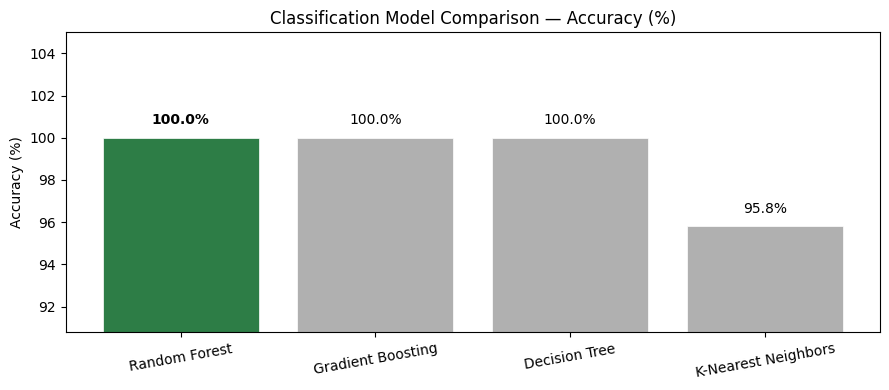

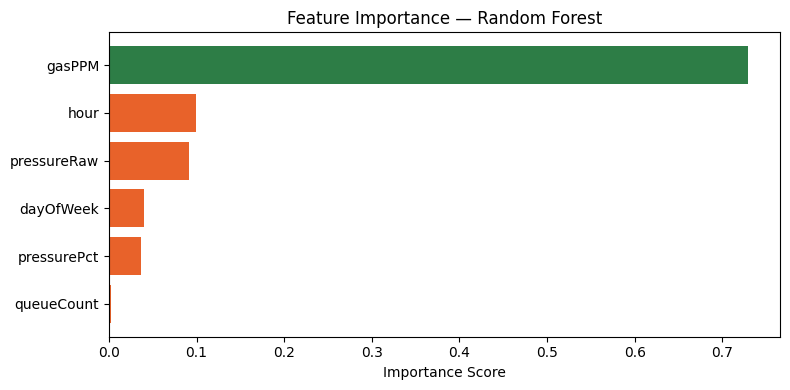


Most important feature: gasPPM


In [ ]:
# ============================================================
# CELL 5 — Analysis 1 — Classification Model Comparison
# ============================================================
print("=" * 60)
print("ANALYSIS 1 — ALERT CLASSIFICATION — MODEL COMPARISON")
print("=" * 60)
print("4 models trained and compared")
print("Best model selected by highest accuracy")
print()

X = df[['gasPPM','pressureRaw','pressurePct',
        'queueCount','hour','dayOfWeek']]
y = df['gasLevel']

le    = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Define all models
models = {
    'Random Forest':       RandomForestClassifier(
                               n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(
                               n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(
                               max_depth=10, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:<25} Accuracy: {acc * 100:.2f}%")

# Select best model
best_name  = max(results, key=results.get)
best_model = models[best_name]
best_acc   = results[best_name]
accuracy   = best_acc

print(f"\nBest model: {best_name} ({best_acc * 100:.2f}%)")
print(f"\nDetailed report for {best_name}:")
print(classification_report(
    y_test, best_model.predict(X_test),
    target_names=le.classes_
))

# Model comparison bar chart
plt.figure(figsize=(9, 4))
names  = list(results.keys())
accs   = [v * 100 for v in results.values()]
colors = ['#2D7D46' if n == best_name else '#B0B0B0' for n in names]
bars   = plt.bar(names, accs, color=colors,
                 edgecolor='white', linewidth=0.5)
plt.ylim(min(accs) - 5, 105)
plt.title('Classification Model Comparison — Accuracy (%)', fontsize=12)
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10,
             fontweight='bold' if names[bars.index(bar)] == best_name
             else 'normal')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(
        best_model.feature_importances_, index=X.columns
    )
    importance = importance.sort_values(ascending=True)
    plt.figure(figsize=(8, 4))
    colors_fi = ['#2D7D46' if v == importance.max()
                 else '#E8622A' for v in importance.values]
    plt.barh(importance.index, importance.values, color=colors_fi)
    plt.title(f'Feature Importance — {best_name}', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMost important feature: {importance.idxmax()}")

clf = best_model

ANALYSIS 2 — ANOMALY DETECTION — MODEL COMPARISON
3 unsupervised models compared
Best model = closest to expected 5% anomaly rate

Isolation Forest          Anomalies: 249 (4.99%)
Local Outlier Factor      Anomalies: 250 (5.01%)
Elliptic Envelope         Anomalies: 250 (5.01%)

Best model: Local Outlier Factor
Anomalies detected: 250 (5.01%)


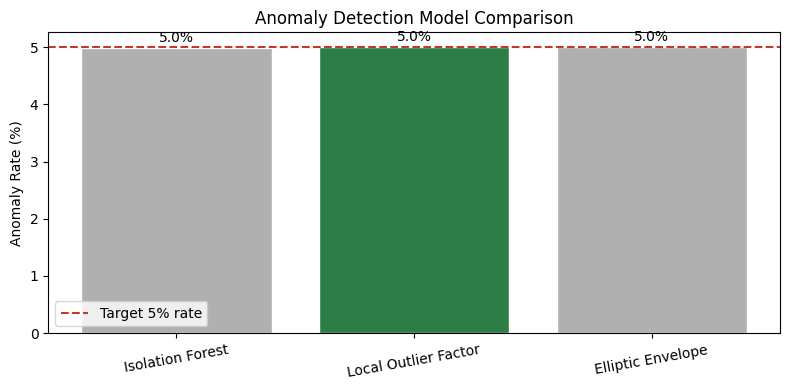

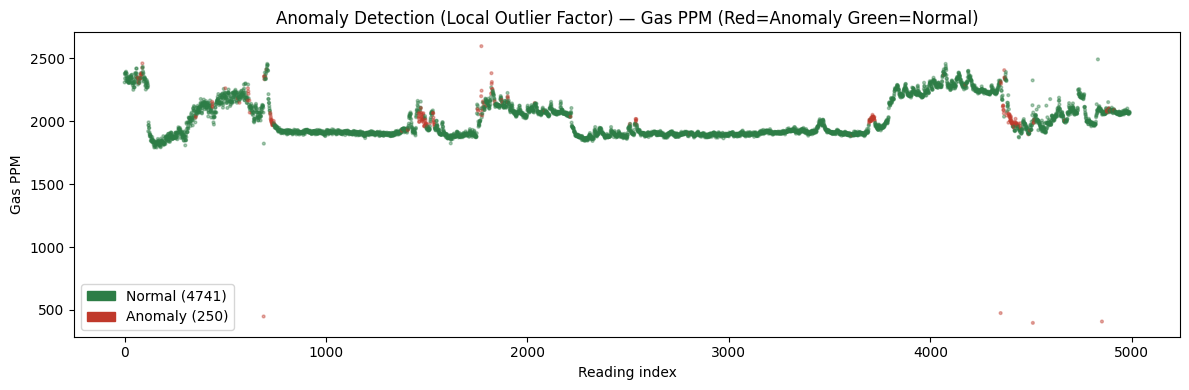

In [ ]:
# ============================================================
# CELL 6 — Analysis 2 — Anomaly Detection Model Comparison
# ============================================================
print("=" * 60)
print("ANALYSIS 2 — ANOMALY DETECTION — MODEL COMPARISON")
print("=" * 60)
print("3 unsupervised models compared")
print("Best model = closest to expected 5% anomaly rate")
print()

features = df[['gasPPM','pressureRaw',
               'pressurePct','queueCount']].copy()

anomaly_models = {
    'Isolation Forest':     IsolationForest(
                                contamination=0.05, random_state=42),
    'Local Outlier Factor': LocalOutlierFactor(
                                n_neighbors=20, contamination=0.05),
    'Elliptic Envelope':    EllipticEnvelope(
                                contamination=0.05, random_state=42),
}

anomaly_results = {}
for name, model in anomaly_models.items():
    try:
        preds       = model.fit_predict(features)
        n_anomalies = (preds == -1).sum()
        rate        = n_anomalies / len(features) * 100
        anomaly_results[name] = {
            'predictions': preds,
            'n_anomalies': n_anomalies,
            'anomaly_rate': rate,
        }
        print(f"{name:<25} Anomalies: {n_anomalies} ({rate:.2f}%)")
    except Exception as e:
        print(f"{name:<25} Failed: {e}")

# Best = closest to 5% target
best_anomaly_name = min(
    anomaly_results,
    key=lambda k: abs(anomaly_results[k]['anomaly_rate'] - 5.0)
)
best_anomaly  = anomaly_results[best_anomaly_name]
anomaly_count = best_anomaly['n_anomalies']
anomaly_rate  = best_anomaly['anomaly_rate']

print(f"\nBest model: {best_anomaly_name}")
print(f"Anomalies detected: {anomaly_count} ({anomaly_rate:.2f}%)")

# Model comparison chart
plt.figure(figsize=(8, 4))
names_a  = list(anomaly_results.keys())
rates    = [anomaly_results[n]['anomaly_rate'] for n in names_a]
colors_a = ['#2D7D46' if n == best_anomaly_name
            else '#B0B0B0' for n in names_a]
plt.bar(names_a, rates, color=colors_a, edgecolor='white')
plt.axhline(y=5, color='#C0392B', linestyle='--',
            label='Target 5% rate')
plt.title('Anomaly Detection Model Comparison', fontsize=12)
plt.ylabel('Anomaly Rate (%)')
for i, (name, rate) in enumerate(zip(names_a, rates)):
    plt.text(i, rate + 0.1, f'{rate:.1f}%',
             ha='center', fontsize=10)
plt.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('anomaly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter plot of best model
df['anomaly']       = best_anomaly['predictions']
df['anomaly_label'] = df['anomaly'].map({1:'Normal', -1:'Anomaly'})

plt.figure(figsize=(12, 4))
colors_s = df['anomaly'].map({1:'#2D7D46', -1:'#C0392B'})
plt.scatter(range(len(df)), df['gasPPM'],
            c=colors_s, alpha=0.4, s=4)
plt.title(f'Anomaly Detection ({best_anomaly_name}) — '
          f'Gas PPM (Red=Anomaly Green=Normal)', fontsize=12)
plt.xlabel('Reading index')
plt.ylabel('Gas PPM')
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#2D7D46',
          label=f'Normal ({len(df)-anomaly_count})'),
    Patch(color='#C0392B',
          label=f'Anomaly ({anomaly_count})')
])
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

ANALYSIS 3 — TEMPORAL TREND — MODEL COMPARISON
3 regression models compared
Best model = highest R² score

Linear Regression         RMSE: 125.88  R²: 0.3125
Ridge Regression          RMSE: 125.88  R²: 0.3125
Gradient Boosting         RMSE: 61.03  R²: 0.8384

Best model: Gradient Boosting (R²=0.8384)


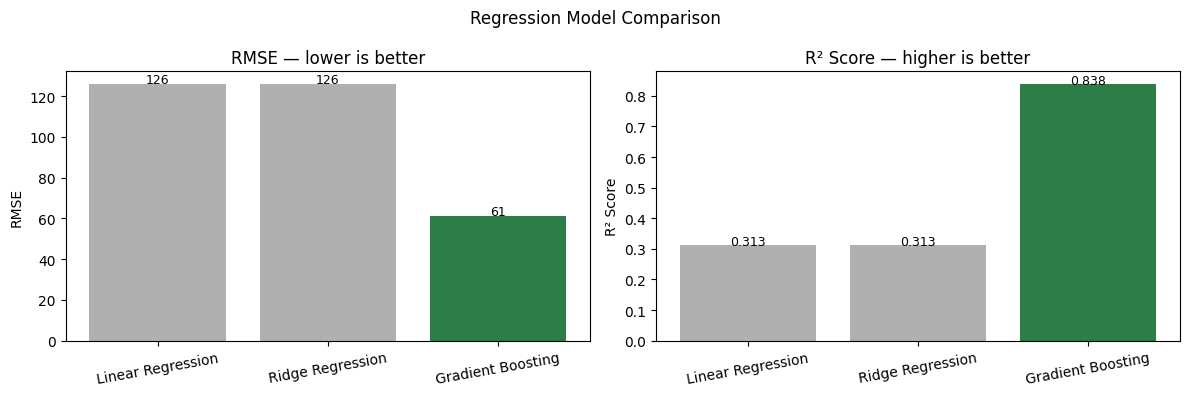

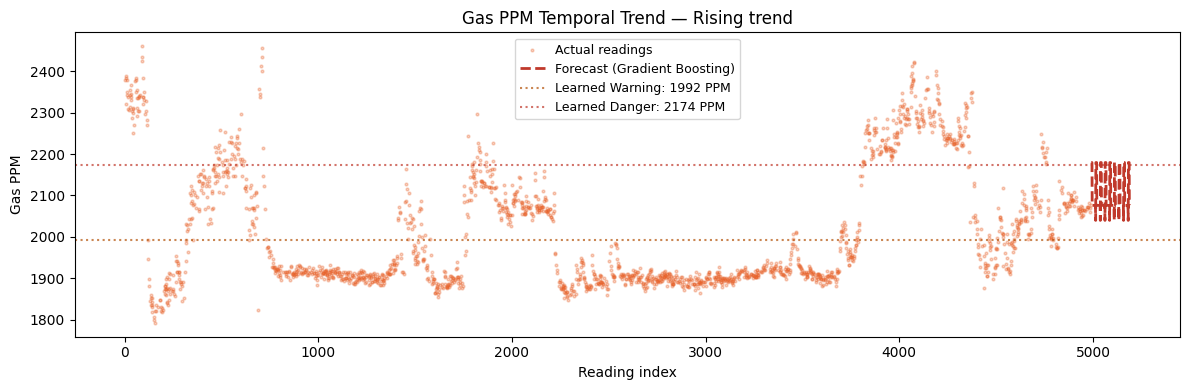


Trend direction:    Rising
Predicted next PPM: 2180
R² score:           0.8384


In [ ]:
# ============================================================
# CELL 7 — Analysis 3 — Temporal Trend Model Comparison
# ============================================================
print("=" * 60)
print("ANALYSIS 3 — TEMPORAL TREND — MODEL COMPARISON")
print("=" * 60)
print("3 regression models compared")
print("Best model = highest R² score")
print()

df['reading_index'] = range(len(df))
X_time = df[['reading_index','hour','dayOfWeek']]
y_gas  = df['gasPPM']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_time, y_gas, test_size=0.2, random_state=42
)

regression_models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Gradient Boosting':  GradientBoostingRegressor(
                              n_estimators=100, random_state=42),
}

reg_results = {}
for name, model in regression_models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    reg_results[name] = {'model': model, 'rmse': rmse, 'r2': r2}
    print(f"{name:<25} RMSE: {rmse:.2f}  R²: {r2:.4f}")

# Best = highest R²
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['r2'])
best_reg      = reg_results[best_reg_name]['model']
best_r2       = reg_results[best_reg_name]['r2']

print(f"\nBest model: {best_reg_name} (R²={best_r2:.4f})")

# Comparison charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names_r  = list(reg_results.keys())
rmses    = [reg_results[n]['rmse'] for n in names_r]
r2s      = [reg_results[n]['r2']   for n in names_r]
colors_r = ['#2D7D46' if n == best_reg_name
            else '#B0B0B0' for n in names_r]

axes[0].bar(names_r, rmses, color=colors_r)
axes[0].set_title('RMSE — lower is better')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=10)
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.5, f'{v:.0f}',
                 ha='center', fontsize=9)

axes[1].bar(names_r, r2s, color=colors_r)
axes[1].set_title('R² Score — higher is better')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=10)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.001, f'{v:.3f}',
                 ha='center', fontsize=9)

plt.suptitle('Regression Model Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('trend_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Forecast using best model
future_df = pd.DataFrame({
    'reading_index': range(len(df), len(df) + 200),
    'hour':          [h % 24 for h in range(200)],
    'dayOfWeek':     [(d // 24) % 7 for d in range(200)],
})
future_gas = best_reg.predict(future_df)

# Trend direction from simple linear regression
simple_lr = LinearRegression()
simple_lr.fit(df[['reading_index']], y_gas)
direction = 'Rising' if simple_lr.coef_[0] > 0 else 'Falling'

# Forecast chart
plt.figure(figsize=(12, 4))
sample = df.sample(min(2000, len(df))).sort_values('reading_index')
plt.scatter(sample['reading_index'], sample['gasPPM'],
            alpha=0.3, s=4, color='#E8622A', label='Actual readings')
plt.plot(future_df['reading_index'], future_gas,
         color='#C0392B', linewidth=2, linestyle='--',
         label=f'Forecast ({best_reg_name})')
plt.axhline(y=learned_safe_warning, color='#B45309',
            linestyle=':', alpha=0.7,
            label=f'Learned Warning: {learned_safe_warning:.0f} PPM')
plt.axhline(y=learned_warning_danger, color='#C0392B',
            linestyle=':', alpha=0.7,
            label=f'Learned Danger: {learned_warning_danger:.0f} PPM')
plt.title(f'Gas PPM Temporal Trend — {direction} trend', fontsize=12)
plt.xlabel('Reading index')
plt.ylabel('Gas PPM')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrend direction:    {direction}")
print(f"Predicted next PPM: {future_gas[0]:.0f}")
print(f"R² score:           {best_r2:.4f}")

reg = best_reg

ANALYSIS 4 — SENSOR CORRELATION ANALYSIS
Correlation Matrix:
             gasPPM  pressureRaw  pressurePct  queueCount
gasPPM        1.000        0.043        0.277       0.061
pressureRaw   0.043        1.000        0.248       0.049
pressurePct   0.277        0.248        1.000       0.257
queueCount    0.061        0.049        0.257       1.000

Gas PPM vs Pressure Raw: 0.0430
Gas PPM vs Queue Count:  0.0605
Pressure vs Queue:       0.0485


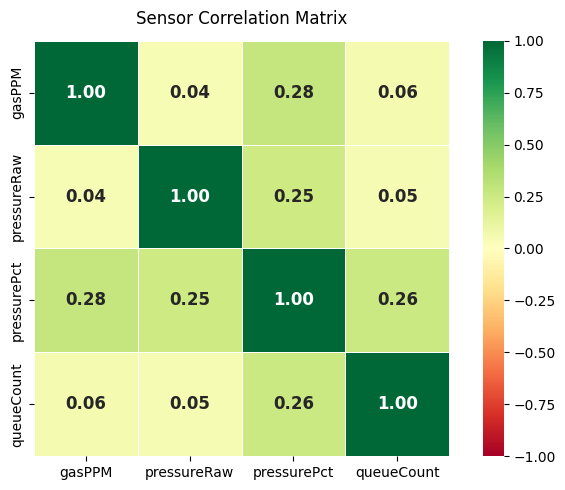

In [ ]:
# ============================================================
# CELL 8 — Analysis 4 — Sensor Correlation
# ============================================================
print("=" * 60)
print("ANALYSIS 4 — SENSOR CORRELATION ANALYSIS")
print("=" * 60)

corr_cols   = ['gasPPM','pressureRaw','pressurePct','queueCount']
correlation = df[corr_cols].corr()

print("Correlation Matrix:")
print(correlation.round(3))
print(f"\nGas PPM vs Pressure Raw: "
      f"{correlation['gasPPM']['pressureRaw']:.4f}")
print(f"Gas PPM vs Queue Count:  "
      f"{correlation['gasPPM']['queueCount']:.4f}")
print(f"Pressure vs Queue:       "
      f"{correlation['pressureRaw']['queueCount']:.4f}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation, annot=True, cmap='RdYlGn',
    fmt='.2f', linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 12, 'weight': 'bold'}, square=True
)
plt.title('Sensor Correlation Matrix', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 9 — Push all results to Firebase
# ============================================================
import firebase_admin
from firebase_admin import credentials, db as rtdb

cred = credentials.Certificate('serviceAccountKey.json')
if not firebase_admin._apps:
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://smartfuelstation-10a27-default-rtdb'
                       '.asia-southeast1.firebasedatabase.app/'
    })

ml_ref = rtdb.reference('/mlInsights')
ml_ref.set({
    # existing fields stay the same
    'classifierAccuracy':      round(float(accuracy * 100), 2),
    'bestClassifier':          best_name,
    'trendDirection':          direction,
    'bestRegressor':           best_reg_name,
    'predictedNextGasPPM':     int(future_gas[0]),
    'anomaliesDetected':       int(anomaly_count),
    'anomalyRate':             round(float(anomaly_rate), 2),
    'bestAnomalyDetector':     best_anomaly_name,
    'totalRecordsAnalyzed':    int(len(df)),
    'topFeature':              str(importance.idxmax())
                               if hasattr(clf,'feature_importances_')
                               else 'gasPPM',
    'lastAnalyzed':            str(pd.Timestamp.now())[:16],

    # Gas learned thresholds
    'learnedSafeWarning':      int(learned_safe_warning),
    'learnedWarningDanger':    int(learned_warning_danger),
    'hardCodedWarning':        3000,
    'hardCodedDanger':         5000,

    # Pressure learned thresholds — NEW
    'learnedPressureWarning':  int(learned_pressure_warning),
    'learnedPressureDanger':   int(learned_pressure_danger),
    'hardCodedPressureWarning': 300000,
    'hardCodedPressureDanger':  800000,
})

print("All ML results pushed to Firebase successfully")
print()
print(f"Classification:     {best_name} — {accuracy*100:.2f}%")
print(f"Anomaly detector:   {best_anomaly_name} — {anomaly_rate:.2f}%")
print(f"Trend regressor:    {best_reg_name} — R²={best_r2:.4f}")
print(f"Trend direction:    {direction}")
print(f"Predicted next PPM: {int(future_gas[0])}")
print(f"Learned thresholds: Warning={int(learned_safe_warning)}"
      f"  Danger={int(learned_warning_danger)}")

All ML results pushed to Firebase successfully

Classification:     Random Forest — 100.00%
Anomaly detector:   Local Outlier Factor — 5.01%
Trend regressor:    Gradient Boosting — R²=0.8384
Trend direction:    Rising
Predicted next PPM: 2179
Learned thresholds: Warning=1992  Danger=2173


In [ ]:
# ============================================================
# CELL 10 — Download all charts
# ============================================================
from google.colab import files

charts = [
    'learned_thresholds.png',
    'learned_pressure_thresholds.png',   # NEW
    'classification_comparison.png',
    'feature_importance.png',
    'anomaly_comparison.png',
    'anomaly_detection.png',
    'trend_comparison.png',
    'trend_analysis.png',
    'correlation_matrix.png',
]

for f in charts:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Skipped (not found): {f}")

print("\nAll charts downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: learned_thresholds.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: trend_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: correlation_matrix.png

All charts downloaded successfully
